In [30]:
import pandas as pd

In [31]:
df = pd.read_csv("Food_Delivery_Times.csv")

In [32]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [34]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [35]:
df_num = df.select_dtypes(include =["number"]).columns
df_cat = df.select_dtypes(include = ["object"]).columns

In [36]:
from sklearn.impute import SimpleImputer

num_ip = SimpleImputer(strategy = "mean")
df[df_num] = num_ip.fit_transform(df[df_num])

cat_ip = SimpleImputer(strategy = "most_frequent")
df[df_cat] = cat_ip.fit_transform(df[df_cat])

In [37]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Distance_km', ylabel='Delivery_Time_min'>

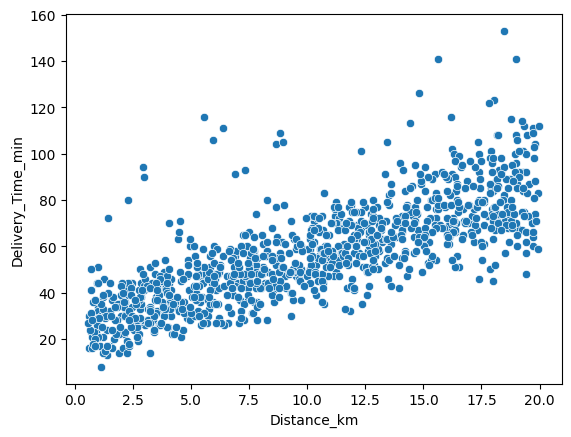

In [39]:
sns.scatterplot(data=df ,  x=df["Distance_km"], y=df["Delivery_Time_min"])

<Axes: xlabel='Traffic_Level', ylabel='Delivery_Time_min'>

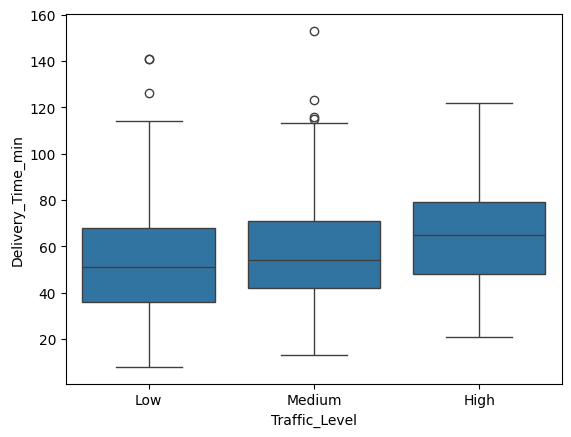

In [40]:
sns.boxplot(data=df , x=df["Traffic_Level"] , y=df["Delivery_Time_min"])

In [41]:
df["Speed"] = df["Distance_km"] / df["Delivery_Time_min"]

In [42]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Speed
0,522.0,7.93,Windy,Low,Afternoon,Scooter,12.0,1.0,43.0,0.184419
1,738.0,16.42,Clear,Medium,Evening,Bike,20.0,2.0,84.0,0.195476
2,741.0,9.52,Foggy,Low,Night,Scooter,28.0,1.0,59.0,0.161356
3,661.0,7.44,Rainy,Medium,Afternoon,Scooter,5.0,1.0,37.0,0.201081
4,412.0,19.03,Clear,Low,Morning,Bike,16.0,5.0,68.0,0.279853


In [43]:
from sklearn.preprocessing import OneHotEncoder
columns = ["Weather" , "Traffic_Level" ,"Time_of_Day" ,"Vehicle_Type"]
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[columns])

encoded_df = pd.DataFrame(encoded , columns = ohe.get_feature_names_out(columns) , index =df.index)

df = pd.concat([df.drop(columns = columns) , encoded_df] , axis =1)

In [44]:
df = df.drop(columns = ["Order_ID"])

In [45]:
df.head()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Speed,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,12.0,1.0,43.0,0.184419,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,16.42,20.0,2.0,84.0,0.195476,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,9.52,28.0,1.0,59.0,0.161356,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,7.44,5.0,1.0,37.0,0.201081,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,19.03,16.0,5.0,68.0,0.279853,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


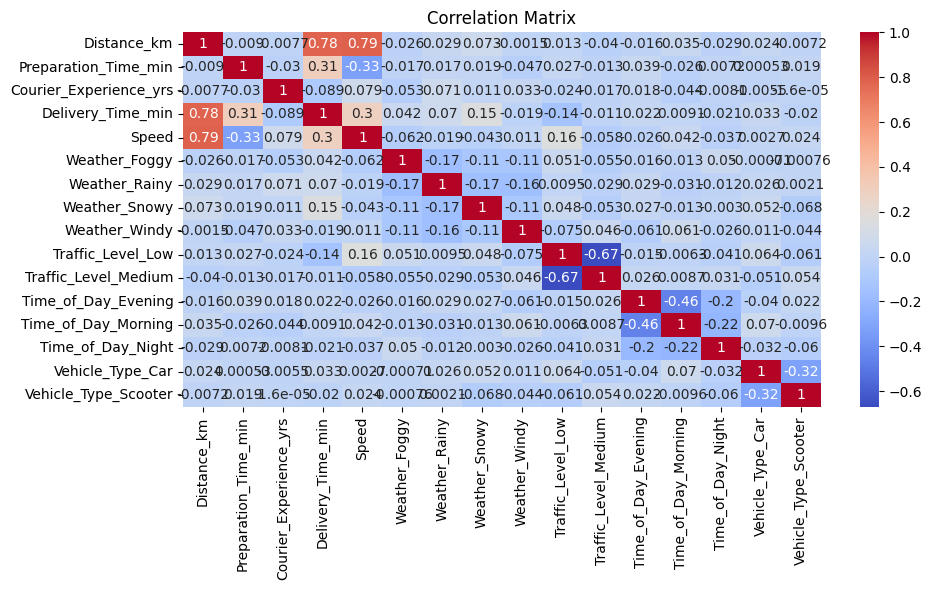

In [46]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr() , annot=True , cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [48]:
X=df.drop(columns = ["Delivery_Time_min"])
y=df["Delivery_Time_min"]

In [49]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size =0.2
)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled , y_train)

LinearRegression()

In [54]:
y_pred = model.predict(X_test_scaled)

In [55]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test , y_pred)

print(r2)

0.8938118556121369


In [56]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test , y_pred)

print(mse)

55.757270855179144


In [60]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train_scaled, y_train)

RandomForestRegressor()

In [61]:
y_predict = rf.predict(X_test_scaled)

In [63]:
r2 = r2_score(y_test , y_predict)

print(r2)

0.9649813142759198


In [64]:
mse = mean_squared_error(y_test , y_predict)

print(mse)

18.387611500000002
